In [1]:
from semantic_workflows.pyiron.thermodynamics import calculate_thermal_properties
from semantic_workflows.pyiron.build import bulk, repeat
from pyiron_workflow import Workflow
from conceptual_dictionary import ConceptualDict 

In [2]:
pair_style = "eam/alloy"
pair_coeff = "* * workflows/potentials/Fe_Ack.eam Fe"

In [3]:
cd = ConceptualDict()

In [4]:
wf = Workflow("thermal_expansion")
wf.bulk = bulk('Fe', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, (3,3,3), cdict=cd)
wf.thermal = calculate_thermal_properties(wf.structure, 
    pair_style, 
    pair_coeff, 
    temperature=293, pressure=0,
    n_run_steps=10000,
    cdict=cd)

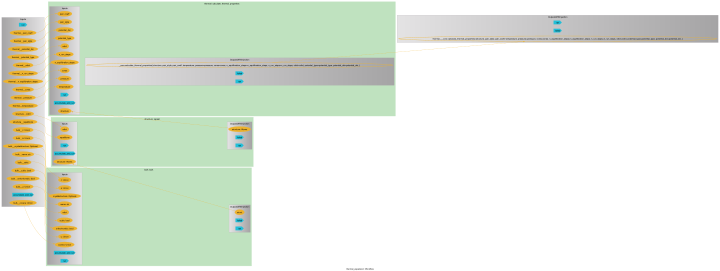

In [5]:
wf.draw(rankdir='LR', size=(10, 10))

In [5]:
wf.run()

{'thermal__results': {'specific_heat': np.float64(0.37443373976832656),
  'thermal_expansion': np.float64(6.407128434562268e-05),
  'volume': np.float64(646.7892482666599)}}

In [6]:
cd.to_yaml('thermal.yaml')